# IMOS Global Reef Fish Abundance & Biomass EDA

This notebook explores the IMOS National Reef Monitoring Network Sub-Facility dataset.

In [1]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except Exception:
    sns = None

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)


## Unformatted Column Descriptions
- The original dataset was prepended with 71 rows of column descriptions. These have been removed from the dataset and stored in `column_descriptions` for reference:

In [2]:
coldesc_df = pd.read_csv('imos_coldescs.csv', sep='\t', dtype=str)
coldesc_df.columns = [col.lstrip('# ').strip() for col in coldesc_df.columns]
if coldesc_df.columns.size > 0:
    first_col = coldesc_df.columns[0]
    coldesc_df[first_col] = coldesc_df[first_col].astype(str).str.lstrip('#').str.strip()
coldesc_df = coldesc_df.fillna('')
coldesc_df

,data_column_name,cf_standard_name,long_name,imos_vocabulary_name,unit_name,unit_short_name
0,abundance,number_concentration_of_biological_taxon_in_se...,taxonomic level abundance,Abundance of biota,,
1,area,,state/territory where the survey was conducted,,,
2,avg_rugosity,,average roughness of the floor surface,,,
3,biomass,,estimated biomass,,Grams,g
4,block,,number of the block,,,
5,category,,sub-class of the annotation schema,,,
6,class,biological_taxon_name,identification of the biotic elements to the s...,Biotic taxonomic identification,,
7,common_class_name,,common name of the taxonomic rank,,,
8,common_family_name,,common name of the taxonomic rank,,,
9,common_name,,common name of the taxonomic rank,,,


In [3]:
DATA_PATH = Path(os.getenv(
    'IMOS_DATASET_PATH',
    # 'IMOS_-_National_Reef_Monitoring_Network_Sub-Facility_-_Global_reef_fish_abundance_and_biomass.csv'
    'IMOS_-_National_Reef_Monitoring_Network_Sub-Facility_-_Global_reef_fish_abundance_and_biomass_complete_trimmed.csv'
))
DATA_PATH


WindowsPath('IMOS_-_National_Reef_Monitoring_Network_Sub-Facility_-_Global_reef_fish_abundance_and_biomass_complete_trimmed.csv')

In [4]:
df = pd.read_csv(DATA_PATH, dtype=str, na_values=[''], engine='python', on_bad_lines='warn', skipinitialspace=True)
df.columns = [col.lstrip('# ').strip() for col in df.columns]
for col in df.columns:
    df[col] = df[col].str.strip()
# robustly handle missing/alternate column names
candidates = [col for col in df.columns if ('data' in col.lower() and 'column' in col.lower() and 'name' in col.lower())]
if candidates:
    if candidates[0] != 'data_column_name':
        df = df.rename(columns={candidates[0]: 'data_column_name'})
    df['data_column_name'] = df['data_column_name'].astype(str).str.lstrip('#').str.strip()
else:
    df['data_column_name'] = np.nan
df.head()


,FID,survey_id,country,area,ecoregion,realm,location,site_code,site_name,latitude,longitude,survey_date,depth,program,visibility,hour,survey_latitude,survey_longitude,method,block,phylum,class,order,family,species_name,reporting_name,size_class,total,biomass,geom,data_column_name
0,ep_m1_public_data.fid--43bec24c_19e67c26e25_-3717,1003264,United States,California,Northern California,Temperate Northern Pacific,Channel Islands,USWC9,Hare Rock San Miguel,34.06,-120.36,2010-09-14,7.1,RLS,NaN,NaN,NaN,NaN,1,1,Chordata,Actinopterygii,Perciformes,Gobiidae,Rhinogobiops nicholsii,Rhinogobiops nicholsii,5,4,8.9985,POINT (-120.36000061035156 34.060001373291016),NaN
1,ep_m1_public_data.fid--43bec24c_19e67c26e25_-3716,1003264,United States,California,Northern California,Temperate Northern Pacific,Channel Islands,USWC9,Hare Rock San Miguel,34.06,-120.36,2010-09-14,7.1,RLS,NaN,NaN,NaN,NaN,1,1,Chordata,Actinopterygii,Perciformes,Gobiidae,Rhinogobiops nicholsii,Rhinogobiops nicholsii,7.5,5,38.1167,POINT (-120.36000061035156 34.060001373291016),NaN
2,ep_m1_public_data.fid--43bec24c_19e67c26e25_-3715,1003264,United States,California,Northern California,Temperate Northern Pacific,Channel Islands,USWC9,Hare Rock San Miguel,34.06,-120.36,2010-09-14,7.1,RLS,NaN,NaN,NaN,NaN,1,1,Chordata,Actinopterygii,Scorpaeniformes,Cottidae,Orthonopias triacis,Orthonopias triacis,5,2,4.8475,POINT (-120.36000061035156 34.060001373291016),NaN
3,ep_m1_public_data.fid--43bec24c_19e67c26e25_-3714,1003264,United States,California,Northern California,Temperate Northern Pacific,Channel Islands,USWC9,Hare Rock San Miguel,34.06,-120.36,2010-09-14,7.1,RLS,NaN,NaN,NaN,NaN,1,1,Chordata,Actinopterygii,Scorpaeniformes,Cottidae,Scorpaenichthys marmoratus,Scorpaenichthys marmoratus,50,2,1198.903,POINT (-120.36000061035156 34.060001373291016),NaN
4,ep_m1_public_data.fid--43bec24c_19e67c26e25_-3713,1003264,United States,California,Northern California,Temperate Northern Pacific,Channel Islands,USWC9,Hare Rock San Miguel,34.06,-120.36,2010-09-14,7.1,RLS,NaN,NaN,NaN,NaN,1,1,Chordata,Actinopterygii,Scorpaeniformes,Hexagrammidae,Ophiodon elongatus,Ophiodon elongatus,50,1,599.4515,POINT (-120.36000061035156 34.060001373291016),NaN


## Metadata


In [5]:
def unique_or_nan(col_name):
    return df[col_name].nunique(dropna=True) if col_name in df.columns else np.nan

file_stats = {
    'file': DATA_PATH.name,
    'file_size_mb': round(DATA_PATH.stat().st_size / (1024 * 1024), 2),
    'rows': len(df),
    'columns': df.shape[1],
    'unique_data_columns': unique_or_nan('data_column_name'),
    'unique_cf_standard_names': unique_or_nan('cf_standard_name'),
    'unique_imos_vocabulary_names': unique_or_nan('imos_vocabulary_name'),
    'unique_units': unique_or_nan('unit_name'),
}
pd.Series(file_stats)


file                            IMOS_-_National_Reef_Monitoring_Network_Sub-Fa...
file_size_mb                                                               614.65
rows                                                                      1809456
columns                                                                        31
unique_data_columns                                                             0
unique_cf_standard_names                                                      NaN
unique_imos_vocabulary_names                                                  NaN
unique_units                                                                  NaN
dtype: object

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1809456 entries, 0 to 1809455
Data columns (total 31 columns):
 #   Column            Dtype  
---  ------            -----  
 0   FID               object 
 1   survey_id         object 
 2   country           object 
 3   area              object 
 4   ecoregion         object 
 5   realm             object 
 6   location          object 
 7   site_code         object 
 8   site_name         object 
 9   latitude          object 
 10  longitude         object 
 11  survey_date       object 
 12  depth             object 
 13  program           object 
 14  visibility        object 
 15  hour              object 
 16  survey_latitude   object 
 17  survey_longitude  object 
 18  method            object 
 19  block             object 
 20  phylum            object 
 21  class             object 
 22  order             object 
 23  family            object 
 24  species_name      object 
 25  reporting_name    object 
 26  size_class    

## Missing Values

- Columns with missing values, 1.0 is completely missing:

In [7]:
missingness = df.isna().mean().sort_values(ascending=False)
completely_missing = missingness[missingness == 1.0]
some_missing = missingness[(missingness > 0.0) & (missingness < 1.0)]
non_missing = missingness[missingness == 0.0]

print(f'Completely missing: {len(completely_missing)}')
print(completely_missing.index.tolist())
print(f'Some missing: {len(some_missing)}')
print(some_missing.index.tolist())
print(f'Fully populated: {len(non_missing)}')
print(non_missing.index.tolist())

Completely missing: 1
['data_column_name']
Some missing: 9
['survey_latitude', 'survey_longitude', 'hour', 'visibility', 'biomass', 'family', 'order', 'country', 'reporting_name']
Fully populated: 21
['FID', 'area', 'ecoregion', 'realm', 'survey_id', 'program', 'depth', 'survey_date', 'longitude', 'site_name', 'latitude', 'site_code', 'location', 'class', 'phylum', 'block', 'method', 'size_class', 'species_name', 'total', 'geom']


In [8]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
FID,1809456,1809456,ep_m1_public_data.fid--43bec24c_19e67d5dcc8_654f,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
survey_id,1809456,33806,912347793,495,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,1809234,59,Australia,1454568,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area,1809456,153,New South Wales,409634,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ecoregion,1809456,104,Cape Howe,266616,NaN,NaN,NaN,NaN,NaN,NaN,NaN
realm,1809456,12,Temperate Australasia,810309,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,1809456,221,Jervis Bay,129975,NaN,NaN,NaN,NaN,NaN,NaN,NaN
site_code,1809456,4787,PS17,13384,NaN,NaN,NaN,NaN,NaN,NaN,NaN
site_name,1809456,4761,Fly Point Nelson Bay,13384,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,1809456,2172,-32.71,38225,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Blacktip reef shark coverage

In [9]:
blacktip_scientific = 'Carcharhinus melanopterus'
blacktip_common = 'blacktip reef shark'

name_cols = [col for col in ['species_name', 'reporting_name'] if col in df.columns]
bt_mask = pd.Series(False, index=df.index)
for col in name_cols:
    bt_mask |= df[col].str.contains(blacktip_scientific, case=False, na=False)
    bt_mask |= df[col].str.contains(blacktip_common, case=False, na=False)

exists = bool(bt_mask.any())
count = int(bt_mask.sum())
print(f'blacktip reef shark exists? {exists}')
print(f'blacktip rows: {count}')

blacktip reef shark exists? True
blacktip rows: 62


Location col: site_name
locations with BRS: 39 / 4761 (0.008)
rows kept: 29118, rows discarded: 1780338
BRS abundance per location (total):
min     1.000000
25%     1.000000
50%     1.000000
mean    1.846154
75%     2.000000
max     8.000000
Name: total_num, dtype: float64
BRS biomass per location (total):
min        510.977900
25%       8271.583000
50%      11033.091000
mean     18176.825941
75%      19304.674000
max     120298.977000
Name: biomass_num, dtype: float64
Total BRS abundance: 72


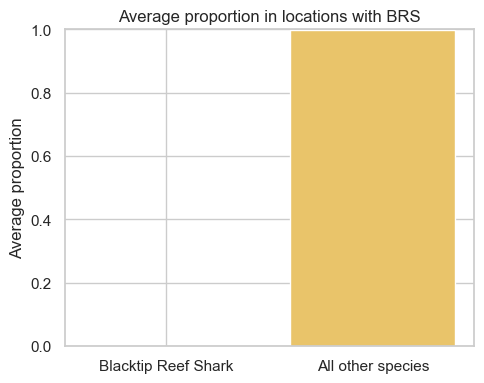

In [10]:
blacktip_scientific = 'Carcharhinus melanopterus'
blacktip_common = 'blacktip reef shark'

name_cols = [col for col in ['species_name', 'reporting_name'] if col in df.columns]
bt_mask = pd.Series(False, index=df.index)
for col in name_cols:
    bt_mask |= df[col].str.contains(blacktip_scientific, case=False, na=False)
    bt_mask |= df[col].str.contains(blacktip_common, case=False, na=False)

df['total_num'] = pd.to_numeric(df['total'], errors='coerce') if 'total' in df.columns else np.nan
df['biomass_num'] = pd.to_numeric(df['biomass'], errors='coerce') if 'biomass' in df.columns else np.nan

preferred_location_cols = ['site_name', 'site_code', 'location', 'survey_id', 'site']
location_col = next((c for c in preferred_location_cols if c in df.columns), None)
if location_col is None:
    fallback = [c for c in df.columns if 'location' in c.lower() or 'site' in c.lower()]
    location_col = fallback[0] if fallback else None

if location_col is None:
    print('No location column found; cannot summarise by location.')
else:
    locations_total = df[location_col].dropna().unique()
    locations_with_blacktip = df.loc[bt_mask, location_col].dropna().unique()
    count_locations_blacktip = len(locations_with_blacktip)
    total_locations = len(locations_total)
    prop_locations_blacktip = (count_locations_blacktip / total_locations) if total_locations else np.nan

    df_kept = df[df[location_col].isin(locations_with_blacktip)]
    rows_kept = len(df_kept)
    rows_discarded = len(df) - rows_kept

    blacktip_abundance = df.loc[bt_mask].groupby(location_col)['total_num'].sum(min_count=1)
    bt_desc = blacktip_abundance.describe(percentiles=[0.25, 0.5, 0.75])
    blacktip_biomass = df.loc[bt_mask].groupby(location_col)['biomass_num'].sum(min_count=1)
    bt_biomass_desc = blacktip_biomass.describe(percentiles=[0.25, 0.5, 0.75])

    print(f'Location col: {location_col}')
    print(f'locations with BRS: {count_locations_blacktip} / {total_locations} ({prop_locations_blacktip:.3f})')
    print(f'rows kept: {rows_kept}, rows discarded: {rows_discarded}')
    print('BRS abundance per location (total):')
    print(bt_desc[['min', '25%', '50%', 'mean', '75%', 'max']])
    if not bt_biomass_desc.empty:
        print('BRS biomass per location (total):')
        print(bt_biomass_desc[['min', '25%', '50%', 'mean', '75%', 'max']])

    total_blacktip = df.loc[bt_mask, 'total_num'].sum(min_count=1)
    print(f'Total BRS abundance: {total_blacktip}')

    total_per_location = df_kept.groupby(location_col)['total_num'].sum(min_count=1)
    blacktip_abundance = blacktip_abundance.reindex(total_per_location.index, fill_value=0)
    proportions = blacktip_abundance / total_per_location
    avg_prop = proportions.mean()
    avg_other = 1 - avg_prop

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.bar(['Blacktip Reef Shark', 'All other species'], [avg_prop, avg_other], color=['#2a9d8f', '#e9c46a'])
    ax.set_ylim(0, 1)
    ax.set_ylabel('Average proportion')
    ax.set_title('Average proportion in locations with BRS')
    plt.tight_layout()